In [ ]:
!pip install requests beautifulsoup4 pillow

Step 1: Scrape all image URLs from the website

In [7]:
import requests
from bs4 import BeautifulSoup

url = "https://angansweets.com"  # replace with actual URL
soup = BeautifulSoup(requests.get(url).text, "html.parser")

image_urls = []
for img in soup.find_all("img"):
    src = img.get("src")
    if src:
        # Make absolute URL if it's relative
        if src.startswith("http"):
            image_urls.append(src)
        else:
            image_urls.append(url.rstrip("/") + "/" + src.lstrip("/"))

print(image_urls)

['https://angansweets.com/images/logo.png', 'https://angansweets.com/_next/image?url=https%3A%2F%2Fwesrjswcgrorgskfwpbp.supabase.co%2Fstorage%2Fv1%2Fobject%2Fpublic%2Fproduct-images%2Fcategories%2Fsweets.jpeg&w=3840&q=75', 'https://angansweets.com/_next/image?url=https%3A%2F%2Fwesrjswcgrorgskfwpbp.supabase.co%2Fstorage%2Fv1%2Fobject%2Fpublic%2Fproduct-images%2Fcategories%2Fsweetsbox.jpg&w=3840&q=75', 'https://angansweets.com/_next/image?url=https%3A%2F%2Fwesrjswcgrorgskfwpbp.supabase.co%2Fstorage%2Fv1%2Fobject%2Fpublic%2Fproduct-images%2Fcategories%2FThali%2520Dry%2520FruitsLarge.jpg&w=3840&q=75', 'https://angansweets.com/_next/image?url=https%3A%2F%2Fwesrjswcgrorgskfwpbp.supabase.co%2Fstorage%2Fv1%2Fobject%2Fpublic%2Fproduct-images%2Fcategories%2Fcombo.jpeg&w=3840&q=75', 'https://angansweets.com/_next/image?url=https%3A%2F%2Fwesrjswcgrorgskfwpbp.supabase.co%2Fstorage%2Fv1%2Fobject%2Fpublic%2Fproduct-images%2Fcategories%2Ffastfood.jpg%0A&w=3840&q=75', 'https://angansweets.com/_next/ima

In [9]:
len(image_urls)

42

Step 2: Download all images

In [12]:
from urllib.parse import urlparse, parse_qs, unquote

BASE_URL = "https://angansweets.com"  # replace with the actual website URL
os.makedirs("downloaded_images", exist_ok=True)

for img_url in image_urls:
    try:
        # Make relative URLs absolute
        if img_url.startswith("/"):
            img_url = BASE_URL + img_url
        
        parsed = urlparse(img_url)
        
        # If it's a Next.js optimized image, extract the real URL
        if "/_next/image" in img_url:
            params = parse_qs(parsed.query)
            real_url = unquote(params["url"][0])
        else:
            real_url = img_url
        
        # Make relative real_urls absolute too
        if real_url.startswith("/"):
            real_url = BASE_URL + real_url

        filename = real_url.split("/")[-1].split("?")[0].strip()
        
        if not filename:  # skip if filename is empty
            print(f"Skipping (no filename): {real_url}")
            continue

        print(f"Downloading: {filename} from {real_url}")
        
        response = requests.get(real_url)
        with open(f"downloaded_images/{filename}", "wb") as f:
            f.write(response.content)

    except Exception as e:
        print(f"Skipping {img_url} — {e}")  # don't crash, just log and move on

Downloading: logo.png from https://angansweets.com/images/logo.png
Downloading: sweets.jpeg from https://wesrjswcgrorgskfwpbp.supabase.co/storage/v1/object/public/product-images/categories/sweets.jpeg
Downloading: sweetsbox.jpg from https://wesrjswcgrorgskfwpbp.supabase.co/storage/v1/object/public/product-images/categories/sweetsbox.jpg
Downloading: Thali Dry FruitsLarge.jpg from https://wesrjswcgrorgskfwpbp.supabase.co/storage/v1/object/public/product-images/categories/Thali Dry FruitsLarge.jpg
Downloading: combo.jpeg from https://wesrjswcgrorgskfwpbp.supabase.co/storage/v1/object/public/product-images/categories/combo.jpeg
Downloading: fastfood.jpg from https://wesrjswcgrorgskfwpbp.supabase.co/storage/v1/object/public/product-images/categories/fastfood.jpg

Downloading: southindian.jpg from https://wesrjswcgrorgskfwpbp.supabase.co/storage/v1/object/public/product-images/categories/southindian.jpg
Downloading: nothindian.jpeg from https://wesrjswcgrorgskfwpbp.supabase.co/storage/v1/ob

In [13]:
import os

files = os.listdir("downloaded_images")
print(f"Total images downloaded: {len(files)}")
for f in files:
    print(f)

Total images downloaded: 41
0vkaj1lvt5gr.png
2pycc8l5fqz.png
5897lzrpzp.png
696s80pc6m9.jpg
69hyyeq6nd.png
7h4tkisim7h.png
9iuc3heag8t.png
9we5q7o4int.png
a191rhf478f.png
bakkery.jpg
Banner1.jpg
Banner2.jpg
Banner3.jpg
Banner4.jpg
bkmg4pf24f.png
cake.jpg
chat.jpg
chinese.jpg
combo.jpeg
fastfood.jpg
feysl87c9lh.png
gfgeorhwsv.png
h2ts19ok3y.png
hj2zpz8nqaf.png
j5u54kmv0np.png
j6br2oi443e.png
logo.png
namkeen.jpg
nothindian.jpeg
o5k9f51w6t.png
pgw415fc35s.png
ql4dgv9gfwj.png
s3by4y5tmk.png
snacks.jpg
southindian.jpg
sweets.jpeg
sweetsbox.jpg
tawandtandori.jpg
Thali Dry FruitsLarge.jpg
ti90b0uj76b.png
tk4n208ycp.png


In [15]:
# checking which image is missed while downloading
# Get all filenames that were successfully downloaded
downloaded = set(os.listdir("downloaded_images"))

# Rebuild what we expected to download
expected = set()
for img_url in image_urls:
    try:
        if img_url.startswith("/"):
            img_url = BASE_URL + img_url
        
        parsed = urlparse(img_url)
        
        if "/_next/image" in img_url:
            params = parse_qs(parsed.query)
            real_url = unquote(params["url"][0])
        else:
            real_url = img_url
        
        if real_url.startswith("/"):
            real_url = BASE_URL + real_url
        
        filename = real_url.split("/")[-1].split("?")[0].strip()
        if filename:
            expected.add(filename)
    except:
        pass

missing = expected - downloaded
print(f"Missing files: {missing}")

Missing files: set()


Step 3: Convert to WebP using Pillow

In [16]:
from PIL import Image
import os

os.makedirs("converted_images", exist_ok=True)
data_map = []

for filename in os.listdir("downloaded_images"):
    input_path = f"downloaded_images/{filename}"
    output_filename = os.path.splitext(filename)[0] + ".webp"
    output_path = f"converted_images/{output_filename}"

    try:
        img = Image.open(input_path)
        img.save(output_path, "WEBP", quality=85)

        data_map.append({
            "original_filename": filename,
            "converted_filename": output_filename
        })
        print(f"Converted: {filename} → {output_filename}")

    except Exception as e:
        print(f"Skipping {filename} — {e}")

print(f"\nDone! {len(data_map)} images converted.")

Converted: 0vkaj1lvt5gr.png → 0vkaj1lvt5gr.webp
Converted: 2pycc8l5fqz.png → 2pycc8l5fqz.webp
Converted: 5897lzrpzp.png → 5897lzrpzp.webp
Converted: 696s80pc6m9.jpg → 696s80pc6m9.webp
Converted: 69hyyeq6nd.png → 69hyyeq6nd.webp
Converted: 7h4tkisim7h.png → 7h4tkisim7h.webp
Converted: 9iuc3heag8t.png → 9iuc3heag8t.webp
Converted: 9we5q7o4int.png → 9we5q7o4int.webp
Converted: a191rhf478f.png → a191rhf478f.webp
Converted: bakkery.jpg → bakkery.webp
Converted: Banner1.jpg → Banner1.webp
Converted: Banner2.jpg → Banner2.webp
Converted: Banner3.jpg → Banner3.webp
Converted: Banner4.jpg → Banner4.webp
Converted: bkmg4pf24f.png → bkmg4pf24f.webp
Skipping cake.jpg — cannot identify image file 'downloaded_images/cake.jpg'
Converted: chat.jpg → chat.webp
Converted: chinese.jpg → chinese.webp
Converted: combo.jpeg → combo.webp
Skipping fastfood.jpg — cannot identify image file 'downloaded_images/fastfood.jpg'
Converted: feysl87c9lh.png → feysl87c9lh.webp
Converted: gfgeorhwsv.png → gfgeorhwsv.webp

Step 4: Generate the data map

In [17]:
import json

with open("data_map.json", "w") as f:
    json.dump(data_map, f, indent=2)

print("data_map.json created!")

data_map.json created!


Checking which format will be better avif or webp

In [18]:
from PIL import Image
import os

# Pick any one image from your downloaded folder
test_image = os.listdir("downloaded_images")[0]
input_path = f"downloaded_images/{test_image}"
base_name = os.path.splitext(test_image)[0]

img = Image.open(input_path)

# Convert to WebP
webp_path = f"{base_name}_test.webp"
img.save(webp_path, "WEBP", quality=85)

# Convert to AVIF
avif_path = f"{base_name}_test.avif"
img.save(avif_path, "AVIF", quality=85)

# Compare file sizes
original_size = os.path.getsize(input_path) / 1024
webp_size = os.path.getsize(webp_path) / 1024
avif_size = os.path.getsize(avif_path) / 1024

print(f"Original:  {original_size:.1f} KB")
print(f"WebP:      {webp_size:.1f} KB  ({((original_size - webp_size)/original_size)*100:.1f}% smaller)")
print(f"AVIF:      {avif_size:.1f} KB  ({((original_size - avif_size)/original_size)*100:.1f}% smaller)")

Original:  312.8 KB
WebP:      34.8 KB  (88.9% smaller)
AVIF:      48.4 KB  (84.5% smaller)


Visual inspection

Original:


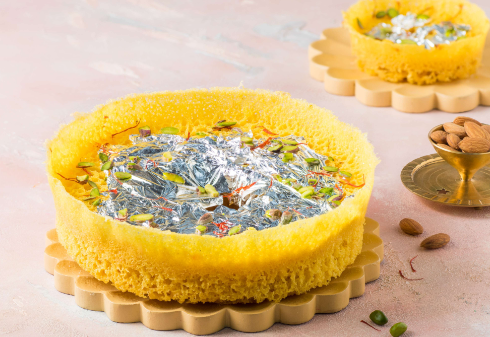

WebP:


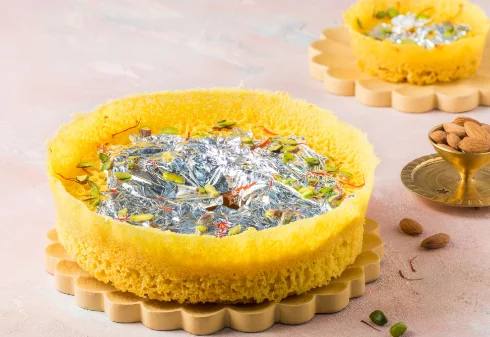

AVIF:


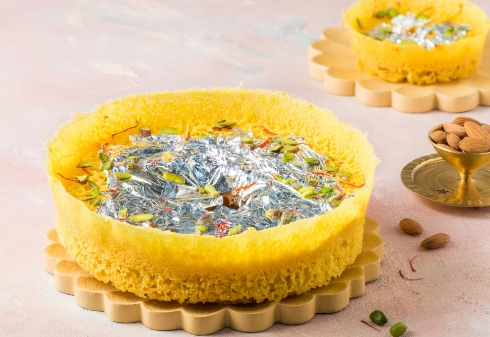

In [19]:
from IPython.display import display
from PIL import Image

print("Original:")
display(Image.open(input_path))

print("WebP:")
display(Image.open(webp_path))

print("AVIF:")
display(Image.open(avif_path))